In [9]:
import sys
from pathlib import Path

import polars as pl
import torch
from torchvision.transforms import v2 as transforms

this_path = Path(__file__) if '__file__' in globals() else Path("<undefined>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

ee_tools_path_p = work_path / Path("ee")
sys.path.append(str(ee_tools_path_p))

import utils
import pl_utils
from datasets import fetch_handler
from ee_tools.ee_refiner import EERefiner
from network import Network, Networks
from exp_manager import ExpManager
from torchvision import models
from analyzer import Analyzer


In [ ]:
pl_utils.Config()
exp_path = this_path.parent
exp_mgr = ExpManager(exp_path=exp_path)

df = exp_mgr.fetch_results(refresh=False)
df = df.filter(pl.col("epochs") == pl.col("epoch").list.last())

# df = df.filter(pl.col("optimizer") == "AdamW")

print(df)

shape: (203, 41)
┌───────────────────────────┬──────────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬─────────────┬───────────┬────────┬────────┬──────┬────────────┬─────────────┬─────────────┬───────┬─────────────────┬─────────────────┬─────┬───────────┬──────────┬────────────┬──────────────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬──────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┐
│ run_id                    ┆ model_arc    ┆ train_dataset  ┆ val_dataset  ┆ num_classes ┆ train_trans               ┆ val_trans                 ┆ train_ndata ┆ val_ndata ┆ epochs 

In [11]:
runs_data = df.to_dicts()

ds_root = work_path / "assets/datasets/"
base_train_ds = fetch_handler(ds_root, "cifar100_train")
base_val_ds = fetch_handler(ds_root, "cifar100_val")

val_trans = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True), base_train_ds.normalizer()]
val_ds = base_val_ds.transform(val_trans)
val_dl = val_ds.loader(batch_size=128)


In [12]:
for run_data in runs_data:
    run_mgr = exp_mgr.get_run(run_data["run_id"])
    sd = torch.load(run_mgr.fpath("state_dict.pt"))

    net_cls = getattr(models, run_data["model_arc"])
    num_classes = run_data["num_classes"]
    div = run_data["div"]

    network = Network(EERefiner(net_cls(num_classes=num_classes)).cifar_style().multi_narrow(div=div, agg="mean").init_weights().build())
    network.load_state_dict_flexible(sd)

    results = (
        Analyzer(network)
               .calc_fire_rate(layer_pattern=r".*relu.*", with_avg=True, with_layer_rates=True, with_neuron_counts=True)
               .calc_dead_neurons(layer_pattern=r".*relu.*", with_avg=True, with_layer_rates=True, with_neuron_counts=True)
               .flow(val_dl)
    )

    avg, layer_rates, layer_neurons = results[0]
    
    # run_mgr.log_param("fire_rate", avg)
    # run_mgr.sync()
    # torch.save(layer_rates, run_mgr.fpath("layer_rates.pt"))
    # torch.save(layer_neurons, run_mgr.fpath("layer_neurons.pt"))

    print(avg)
    print(layer_rates)
    print(layer_neurons)
# exp_mgr.ref_results()

FileNotFoundError: [Errno 2] No such file or directory: '/home/tat/research/ee/ee_experiments/20251211_main_exp_re/exp_model_re/runs/run_2025-12-16_15-51-51_264974/state_dict.pt'

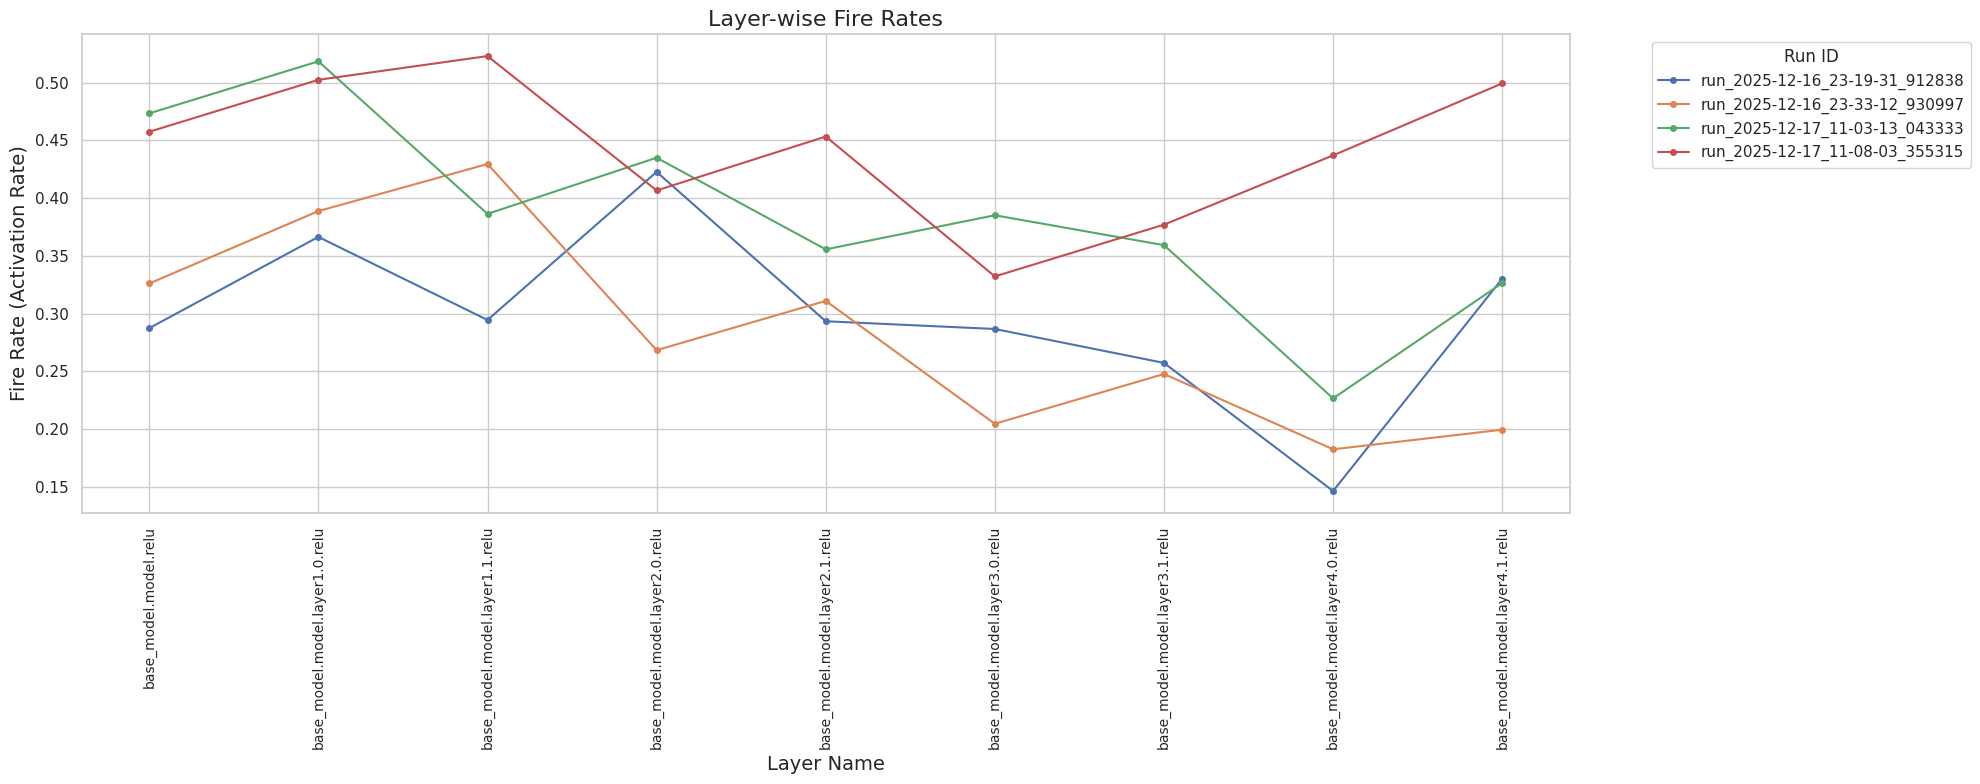

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns # スタイル調整用（任意）

# グラフのスタイル設定 (お好みで)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 8)  # 横幅を大きく取る

# プロットの準備
plt.figure()

# 保存済みのデータをロードしてプロット
for run_data in runs_data:
    run_id = run_data["run_id"]
    
    # ファイルパスの取得
    run_mgr = exp_mgr.get_run(run_id)
    pt_path = run_mgr.fpath("layer_rates.pt")
    
    if not pt_path.exists():
        print(f"Skipping {run_id}: layer_rates.pt not found.")
        continue
    
    # データのロード (Dict[str, float])
    layer_rates = torch.load(pt_path)
    
    # X軸(層名)とY軸(発火率)のデータ作成
    layers = list(layer_rates.keys())
    rates = list(layer_rates.values())
    
    # プロット (マーカー付きで見やすく)
    # labelにrun_idを指定
    plt.plot(layers, rates, marker='o', markersize=4, linestyle='-', label=run_id)


# グラフの装飾
plt.title("Layer-wise Fire Rates", fontsize=16)
plt.ylabel("Fire Rate (Activation Rate)", fontsize=14)
plt.xlabel("Layer Name", fontsize=14)

# X軸ラベルの調整 (層名が重ならないように回転)
plt.xticks(rotation=90, fontsize=10)

# 凡例の表示
plt.legend(title="Run ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 表示
plt.show()